# Exploratory Analysis: ICCP Round-Robin Vitrinite & Bituminite Reflectance Data

**Source:** Kus, J. et al., *Reflectance data from vitrinite and bituminite in the Kimmeridge Clay Formation
supporting the ICCP Identification of Dispersed Organic Matter Working Group round robin exercises from 2016 to 2020*,
U.S. Geological Survey. DOI: [10.5066/P14MGGQM](https://doi.org/10.5066/P14MGGQM)

**What this data is:** Three inter-laboratory round-robin exercises (2016, 2018, 2020) in which anonymous analysts
(labs) measured random vitrinite reflectance (**VRo%**) and bituminite reflectance (**BitRo%**) on the same
Kimmeridge Clay Formation sample material. For each analyst/year/parameter we have:

| Suffix | Meaning |
|---|---|
| (no suffix) | Mean reflectance (%) |
| `SD` | Standard deviation of that analyst's measurements |
| `N` | Number of individual measurements the mean is based on |
| `UMSD` | Unsigned multiple of standard deviation (a standardized deviation-from-consensus metric) |

`n.d.` = not determined (that analyst did not participate / report a value for that year+parameter).

This notebook: loads and cleans the data, profiles missingness, computes descriptive statistics per year/parameter,
compares VRo vs BitRo, compares analysts across years, and visualizes distributions and inter-lab spread
(a classic round-robin reproducibility question).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.dpi'] = 100

CSV_PATH = "table_1.csv"  # place table_1.csv in the same folder as this notebook
raw = pd.read_csv(CSV_PATH, na_values=["n.d.", "n.d ", " n.d."])
raw.head()

,Analyst,2016 VRo,2016 VRo SD,2016 VRo N,2016 VRo UMSD,2016 BitRo,2016 BitRo SD,2016 BitRo N,2016 BitRo UMSD,2018 VRo,2018 VRo SD,2018 VRo N,2018 VRo UMSD,2018 BitRo,2018 BitRo SD,2018 BitRo N,2018 BitRo UMSD,2020 VRo,2020 VRo SD,2020 VRo N,2020 VRo UMSD,2020 BitRo,2020 BitRo SD,2020 BitRo N,2020 BitRo UMSD
0,1,0.40,0.09,9.0,0.754,0.12,0.02,53.0,1.379,0.37,0.05,9.0,0.852,0.09,0.03,23.0,2.380,0.7,0.09,30.0,0.088,0.1,0.05,10.0,1.497
1,2,0.49,0.09,80.0,0.181,0.13,0.03,100.0,1.184,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,0.35,0.07,31.0,1.201,0.20,0.04,59.0,0.178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.41,0.03,17.0,0.543,0.15,0.04,20.0,1.118,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.57,0.04,20.0,0.990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Reshape to long (tidy) format

The wide CSV encodes `Year`, `Parameter` (VRo/BitRo) and `Metric` (mean/SD/N/UMSD) in the column names.
We melt it into a tidy long table which is much easier to filter, group, and plot.

In [2]:
def parse_col(col):
    if col == "Analyst":
        return None
    parts = col.split()
    year = parts[0]
    param = parts[1]  # VRo or BitRo
    metric = parts[2] if len(parts) > 2 else "Mean"
    return year, param, metric

records = []
for col in raw.columns:
    parsed = parse_col(col)
    if parsed is None:
        continue
    year, param, metric = parsed
    for analyst, val in zip(raw["Analyst"], raw[col]):
        records.append({"Analyst": analyst, "Year": int(year), "Parameter": param, "Metric": metric, "Value": val})

long_df = pd.DataFrame(records)

# Pivot metric back out into columns, keeping Analyst/Year/Parameter as the row key
tidy = long_df.pivot_table(index=["Analyst", "Year", "Parameter"], columns="Metric", values="Value", aggfunc="first").reset_index()
tidy = tidy.rename(columns={"Mean": "Reflectance"})
tidy = tidy[["Analyst", "Year", "Parameter", "Reflectance", "SD", "N", "UMSD"]]
tidy.head(10)

Metric,Analyst,Year,Parameter,Reflectance,SD,N,UMSD
0,1,2016,BitRo,0.12,0.02,53.0,1.379
1,1,2016,VRo,0.40,0.09,9.0,0.754
2,1,2018,BitRo,0.09,0.03,23.0,2.380
3,1,2018,VRo,0.37,0.05,9.0,0.852
4,1,2020,BitRo,0.10,0.05,10.0,1.497
5,1,2020,VRo,0.70,0.09,30.0,0.088
6,2,2016,BitRo,0.13,0.03,100.0,1.184
7,2,2016,VRo,0.49,0.09,80.0,0.181
8,3,2016,BitRo,0.20,0.04,59.0,0.178
9,3,2016,VRo,0.35,0.07,31.0,1.201


## 2. Missingness / participation overview

How many analysts reported data for each year and parameter? Round-robin studies often have uneven participation across rounds.

In [3]:
participation = (tidy.dropna(subset=["Reflectance"])
                     .groupby(["Year", "Parameter"])["Analyst"]
                     .nunique()
                     .unstack())
participation

Parameter,BitRo,VRo
Year,,
2016,21,22
2018,20,20
2020,19,19


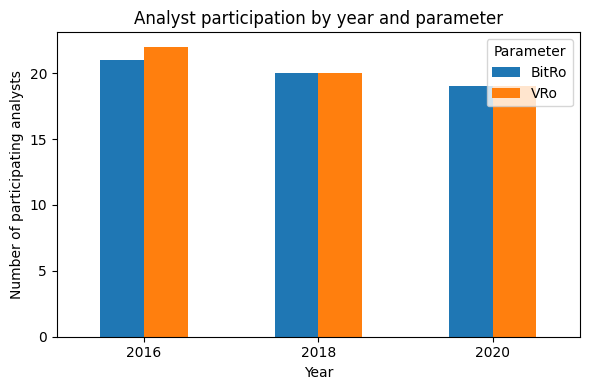

In [4]:
fig, ax = plt.subplots(figsize=(6,4))
participation.plot(kind="bar", ax=ax)
ax.set_ylabel("Number of participating analysts")
ax.set_title("Analyst participation by year and parameter")
ax.set_xlabel("Year")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Descriptive statistics per year / parameter

Across-analyst mean, standard deviation (a measure of *inter-laboratory* reproducibility), min/max, and count of contributing analysts.

In [5]:
desc = (tidy.dropna(subset=["Reflectance"])
            .groupby(["Year", "Parameter"])["Reflectance"]
            .agg(n_analysts="count", mean="mean", std="std", min="min", max="max")
            .round(3))
desc

n_analysts   mean    std   min   max
Year Parameter                                      
2016 BitRo              21  0.191  0.052  0.11  0.29
     VRo                22  0.472  0.100  0.34  0.74
2018 BitRo              20  0.194  0.042  0.09  0.28
     VRo                20  0.454  0.109  0.23  0.70
2020 BitRo              19  0.354  0.169  0.09  0.59
     VRo                19  0.709  0.095  0.54  0.98

**Coefficient of variation** (std/mean) lets us compare reproducibility of VRo vs BitRo on a common scale, since BitRo tends to run lower and noisier than VRo.

In [6]:
desc["cv_pct"] = (desc["std"] / desc["mean"] * 100).round(1)
desc

n_analysts   mean    std   min   max  cv_pct
Year Parameter                                              
2016 BitRo              21  0.191  0.052  0.11  0.29    27.2
     VRo                22  0.472  0.100  0.34  0.74    21.2
2018 BitRo              20  0.194  0.042  0.09  0.28    21.6
     VRo                20  0.454  0.109  0.23  0.70    24.0
2020 BitRo              19  0.354  0.169  0.09  0.59    47.7
     VRo                19  0.709  0.095  0.54  0.98    13.4

## 4. Distribution comparison: VRo vs BitRo, by year

Boxplots of the reported mean reflectance values from each analyst, split by parameter and year.

/tmp/ipykernel_524/963560102.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=["VRo", "BitRo"], showmeans=True)
/tmp/ipykernel_524/963560102.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=["VRo", "BitRo"], showmeans=True)
/tmp/ipykernel_524/963560102.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=["VRo", "BitRo"], showmeans=True)


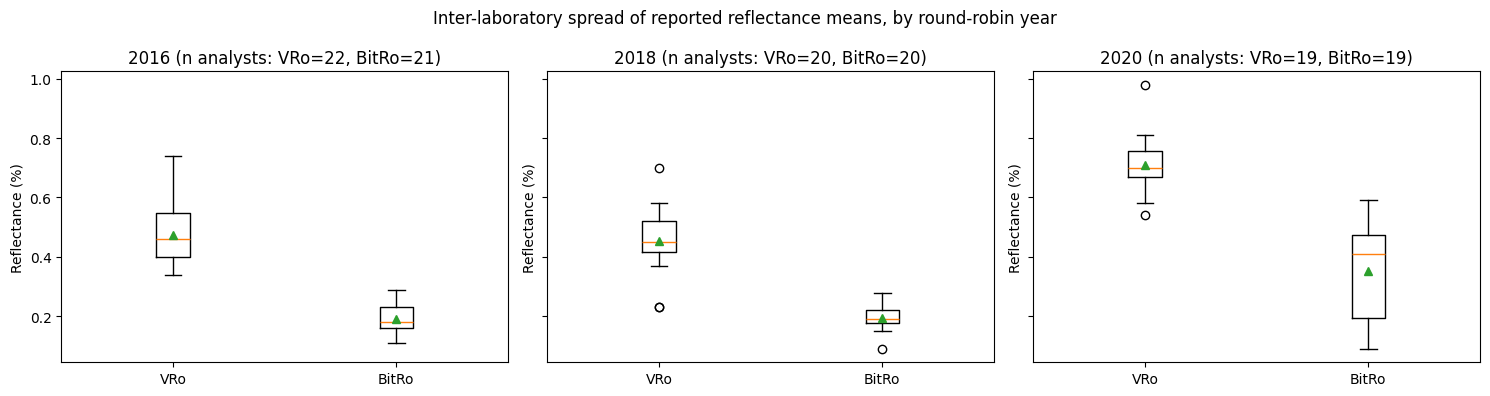

In [7]:
years = sorted(tidy["Year"].unique())
fig, axes = plt.subplots(1, len(years), figsize=(5*len(years), 4), sharey=True)

for ax, year in zip(axes, years):
    sub = tidy[tidy["Year"] == year]
    data_to_plot = [sub[sub["Parameter"]==p]["Reflectance"].dropna() for p in ["VRo", "BitRo"]]
    ax.boxplot(data_to_plot, labels=["VRo", "BitRo"], showmeans=True)
    ax.set_title(f"{year} (n analysts: VRo={len(data_to_plot[0])}, BitRo={len(data_to_plot[1])})")
    ax.set_ylabel("Reflectance (%)")

plt.suptitle("Inter-laboratory spread of reported reflectance means, by round-robin year")
plt.tight_layout()
plt.show()

## 5. Trend across rounds (2016 -> 2018 -> 2020)

Did the consensus value or the spread among labs shift between rounds? A tightening spread over successive rounds would suggest the working group's guidance/calibration was improving reproducibility.

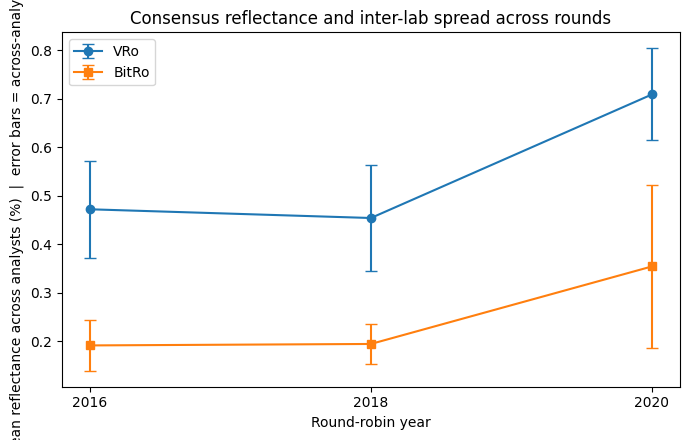

In [8]:
fig, ax = plt.subplots(figsize=(7,4.5))
for param, marker in zip(["VRo", "BitRo"], ["o", "s"]):
    means = desc.xs(param, level="Parameter")["mean"]
    stds = desc.xs(param, level="Parameter")["std"]
    ax.errorbar(means.index, means.values, yerr=stds.values, marker=marker, capsize=4, label=param)

ax.set_xticks(years)
ax.set_xlabel("Round-robin year")
ax.set_ylabel("Mean reflectance across analysts (%)  |  error bars = across-analyst SD")
ax.set_title("Consensus reflectance and inter-lab spread across rounds")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Analyst-level consistency

For analysts who participated in more than one round, how consistent were their own reported values across years? This flags analysts whose measurements moved a lot between rounds vs. those who were stable.

In [9]:
multi_round = (tidy.dropna(subset=["Reflectance"])
                   .groupby(["Analyst", "Parameter"])["Year"]
                   .nunique())
repeat_analysts = multi_round[multi_round > 1].reset_index()["Analyst"].unique()

pivot_vro = (tidy[(tidy["Parameter"]=="VRo") & (tidy["Analyst"].isin(repeat_analysts))]
             .pivot(index="Analyst", columns="Year", values="Reflectance"))
pivot_bitro = (tidy[(tidy["Parameter"]=="BitRo") & (tidy["Analyst"].isin(repeat_analysts))]
               .pivot(index="Analyst", columns="Year", values="Reflectance"))

print("VRo -- analysts with data in >1 round:")
display(pivot_vro)
print("\nBitRo -- analysts with data in >1 round:")
display(pivot_bitro)

VRo -- analysts with data in >1 round:


Year,2016,2018,2020
Analyst,,,
1,0.40,0.37,0.70
5,0.40,0.53,0.67
6,NaN,0.53,0.68
7,0.40,0.52,0.67
8,0.53,0.51,0.79
9,0.43,0.43,0.76
11,0.41,0.56,0.98
12,0.58,0.38,0.71
13,0.56,0.44,0.75



BitRo -- analysts with data in >1 round:


Year,2016,2018,2020
Analyst,,,
1,0.12,0.09,0.10
5,0.16,0.19,0.58
6,NaN,0.20,0.58
7,0.16,0.19,0.59
8,0.22,0.18,0.44
9,0.22,0.15,0.09
11,0.18,0.28,0.46
12,0.20,0.18,0.14
13,0.13,0.18,0.23


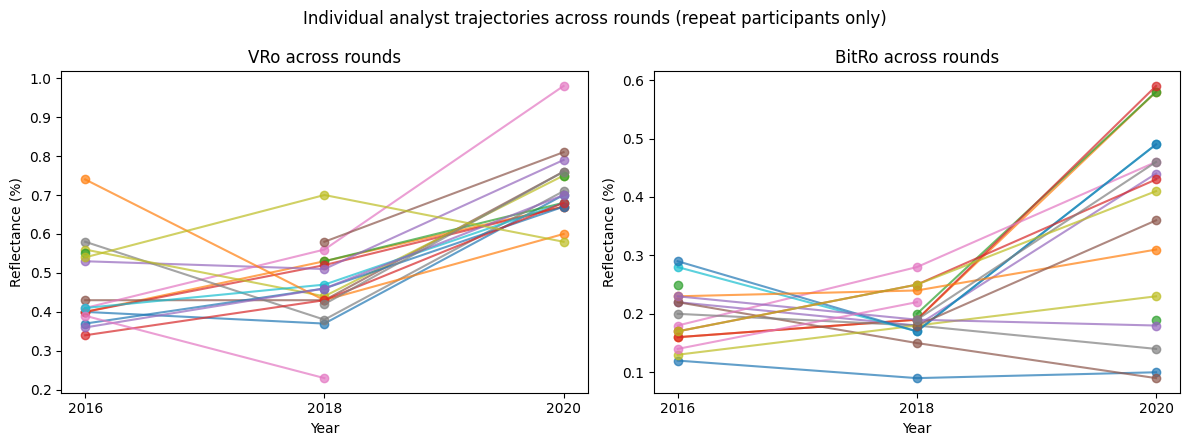

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5), sharey=False)
for ax, pivot, title in zip(axes, [pivot_vro, pivot_bitro], ["VRo across rounds", "BitRo across rounds"]):
    for analyst, row in pivot.iterrows():
        ax.plot(row.index, row.values, marker='o', alpha=0.7, label=f"Analyst {analyst}")
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel("Reflectance (%)")
    ax.set_xticks(years)
plt.suptitle("Individual analyst trajectories across rounds (repeat participants only)")
plt.tight_layout()
plt.show()

## 7. Relationship between measurement count (N) and precision (SD)

Do analysts who ran more individual measurements (higher N) report lower standard deviations? This is a basic sanity check on measurement practice.

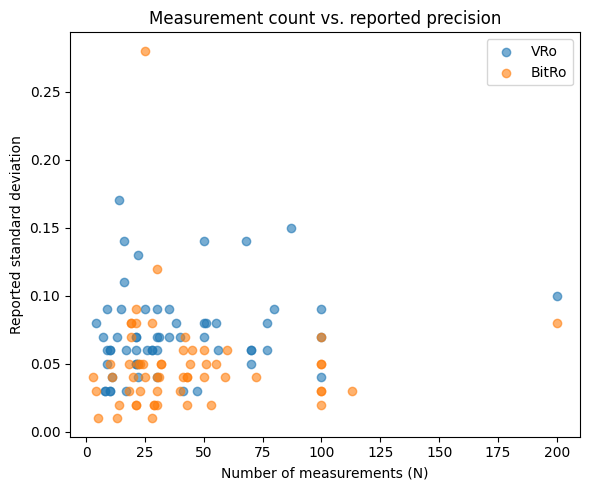

VRo: correlation(N, SD) = 0.207  (n=60)
BitRo: correlation(N, SD) = 0.013  (n=59)


In [11]:
fig, ax = plt.subplots(figsize=(6,5))
for param, color in zip(["VRo","BitRo"], ["tab:blue","tab:orange"]):
    sub = tidy[tidy["Parameter"]==param].dropna(subset=["N","SD"])
    ax.scatter(sub["N"], sub["SD"], alpha=0.6, label=param, color=color)

ax.set_xlabel("Number of measurements (N)")
ax.set_ylabel("Reported standard deviation")
ax.set_title("Measurement count vs. reported precision")
ax.legend()
plt.tight_layout()
plt.show()

# Quick correlation check
for param in ["VRo", "BitRo"]:
    sub = tidy[tidy["Parameter"]==param].dropna(subset=["N","SD"])
    corr = sub["N"].corr(sub["SD"])
    print(f"{param}: correlation(N, SD) = {corr:.3f}  (n={len(sub)})")

## 8. Outlier / high-UMSD analysts

`UMSD` (unsigned multiple of standard deviation) flags how far an analyst's mean deviates from the round's consensus, in units of the round's pooled SD. Values well above 1-2 indicate an analyst was an outlier for that round.

In [12]:
outliers = (tidy.dropna(subset=["UMSD"])
                .sort_values("UMSD", ascending=False)
                .head(15))
outliers

Metric,Analyst,Year,Parameter,Reflectance,SD,N,UMSD
47,11,2020,VRo,0.98,0.15,87.0,2.836
74,17,2016,VRo,0.74,0.14,50.0,2.665
2,1,2018,BitRo,0.09,0.03,23.0,2.380
118,29,2018,VRo,0.70,0.10,200.0,2.223
102,24,2018,VRo,0.23,0.06,10.0,2.151
106,25,2018,VRo,0.23,0.06,10.0,2.151
44,11,2018,BitRo,0.28,0.09,21.0,1.990
67,16,2016,BitRo,0.29,0.01,28.0,1.928
114,28,2020,VRo,0.54,0.08,55.0,1.824
61,15,2016,BitRo,0.28,0.01,13.0,1.693


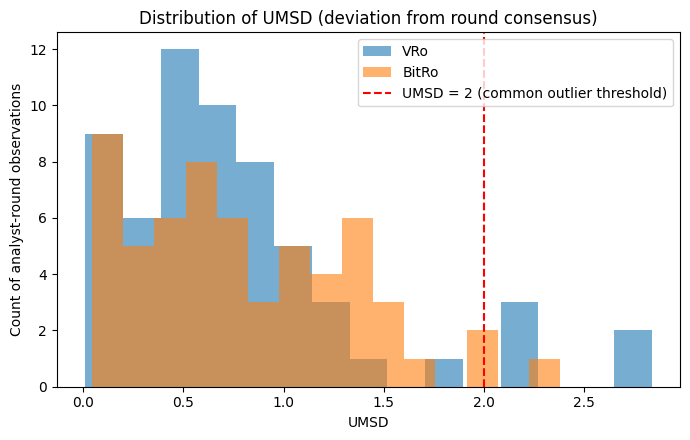

In [13]:
fig, ax = plt.subplots(figsize=(7,4.5))
for param, color in zip(["VRo","BitRo"], ["tab:blue","tab:orange"]):
    sub = tidy[tidy["Parameter"]==param].dropna(subset=["UMSD"])
    ax.hist(sub["UMSD"], bins=15, alpha=0.6, label=param, color=color)
ax.axvline(2, color="red", linestyle="--", label="UMSD = 2 (common outlier threshold)")
ax.set_xlabel("UMSD")
ax.set_ylabel("Count of analyst-round observations")
ax.set_title("Distribution of UMSD (deviation from round consensus)")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Summary

**Participation**: 2016 VRo had the most participants (22 analysts); BitRo trailed slightly at 21. Participation declined steadily each round -- both parameters were down to 19 analysts by 2020, roughly a 14% drop in turnout from 2016 to 2020.

**Reproducibility (across-analyst SD)**: The two parameters moved in opposite directions. VRo's spread was essentially flat to slightly *improving* (SD 0.100 -> 0.109 -> 0.095). BitRo's spread first tightened (0.052 -> 0.042 from 2016 to 2018) but then blew out sharply to 0.169 in 2020 -- roughly 4x the 2018 value. So reproducibility did not improve monotonically across rounds; BitRo reproducibility actually got much worse by the final round.

**VRo vs BitRo (CV%)**: 
| Year | VRo CV% | BitRo CV% |
|---|---|---|
| 2016 | 21.2 | 27.2 |
| 2018 | 24.0 | 21.6 |
| 2020 | 13.4 | 47.7 |

BitRo was noisier than VRo in 2016 and dramatically noisier in 2020 (47.7% vs 13.4%), consistent with the expectation that bituminite reflectance is harder to measure consistently. 2018 is the exception, where BitRo was briefly *more* consistent than VRo. Overall, the data supports the general pattern that BitRo is the less reproducible parameter, especially by the final round.

**Outlier analysts (highest UMSD)**: A few analysts recur as outliers across rounds -- Analyst 1 appears three times in the top 15 UMSD values (2016, 2018, and 2020 BitRo), and Analyst 11 appears twice (2018 BitRo and 2020 VRo). But most of the top-15 outlier observations belong to different analysts each round (e.g. 17, 29, 24/25, 16, 28, 26, 9, 15, 7), so outlier status is mostly round-specific rather than a small fixed group of chronically deviant labs -- with Analyst 1 as a notable recurring exception worth flagging to the working group.

**N vs SD**: There is no meaningful evidence that measuring more points buys tighter precision. The correlation between N and SD is weakly *positive* for VRo (r = 0.207, n = 60) and essentially zero for BitRo (r = 0.013, n = 59). If anything this runs opposite to the naive expectation (more measurements -> lower SD); it's more likely that analysts scale N to sample heterogeneity or measurement difficulty rather than N driving precision directly.